# Predicting High-Value Orders in Balaji Fast Food Sales

This notebook is a clean, GitHub-ready version of the final project workflow.

## Objective
Build and compare multiple machine learning models to predict whether an order is **high value** or **low value**.

### Target definition
`high_value_order = 1 if transaction_amount >= 240 else 0`

### Why classification instead of raw sales regression?
Because `transaction_amount = item_price * quantity`, direct regression would create a trivial target leakage problem. To make the project more realistic, we predict the *order class* using contextual features and exclude both `transaction_amount` and `quantity` from the feature set.


In [10]:
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn"
]

for p in packages:
    try:
        __import__(p if p != "scikit-learn" else "sklearn")
    except ImportError:
        install(p)

print("✅ All packages installed")

✅ All packages installed


In [11]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

## 1. Load the dataset

In [12]:
possible_paths = [
    Path('../data/Balaji Fast Food Sales.csv'),
    Path('data/Balaji Fast Food Sales.csv'),
    Path('Balaji Fast Food Sales.csv'),
    Path('/mnt/data/Balaji Fast Food Sales.csv'),
]

data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find 'Balaji Fast Food Sales.csv'. "
        "Place the CSV in the notebook folder, a ./data folder, or a ../data folder."
    )

print(f'Loaded file: {data_path.resolve()}')
df = pd.read_csv(data_path)
df.head()

Loaded file: C:\Users\Admin\Downloads\Balaji_ML_Project_Package\balaji_ml_project\data\Balaji Fast Food Sales.csv


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


## 2. Basic inspection

In [13]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isna().sum())
print('\nUnique menu items:', df['item_name'].nunique())
print('\nTransaction amount summary:')
print(df['transaction_amount'].describe())

Shape: (1000, 10)

Missing values:
order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

Unique menu items: 7

Transaction amount summary:
count    1000.000000
mean      275.230000
std       204.402979
min        20.000000
25%       120.000000
50%       240.000000
75%       360.000000
max       900.000000
Name: transaction_amount, dtype: float64


## 3. Date cleaning and feature engineering

In [14]:
def parse_mixed_date(x):
    s = str(x)
    if '-' in s:
        return pd.to_datetime(s, format='%d-%m-%Y', errors='coerce')
    if '/' in s:
        return pd.to_datetime(s, format='%m/%d/%Y', errors='coerce')
    return pd.to_datetime(s, errors='coerce')

df['date_parsed'] = df['date'].apply(parse_mixed_date)
df['month'] = df['date_parsed'].dt.month
df['day'] = df['date_parsed'].dt.day
df['dayofweek'] = df['date_parsed'].dt.dayofweek
df['day_name'] = df['date_parsed'].dt.day_name()
df['weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
df['quarter'] = df['date_parsed'].dt.quarter

df['high_value_order'] = (df['transaction_amount'] >= df['transaction_amount'].median()).astype(int)
df[['date', 'date_parsed', 'month', 'dayofweek', 'weekend', 'high_value_order']].head()

,date,date_parsed,month,dayofweek,weekend,high_value_order
0,07-03-2022,2022-03-07,3,0,0,1
1,8/23/2022,2022-08-23,8,1,0,1
2,11/20/2022,2022-11-20,11,6,1,0
3,02-03-2023,2023-03-02,3,3,0,0
4,10-02-2022,2022-02-10,2,3,0,0


## 4. EDA

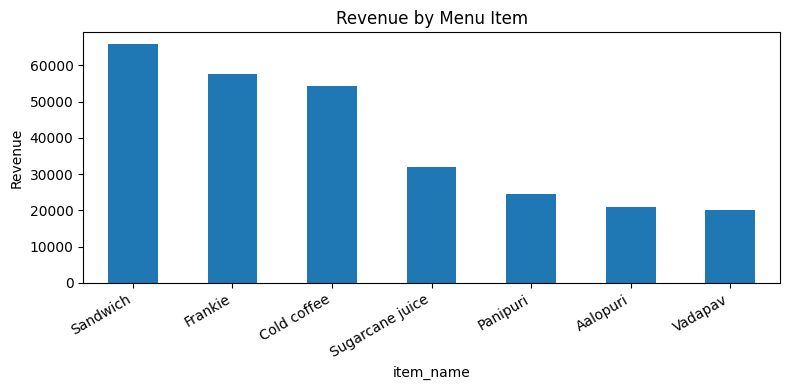

In [15]:
# Revenue by item
item_rev = df.groupby('item_name')['transaction_amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
item_rev.plot(kind='bar')
plt.title('Revenue by Menu Item')
plt.ylabel('Revenue')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

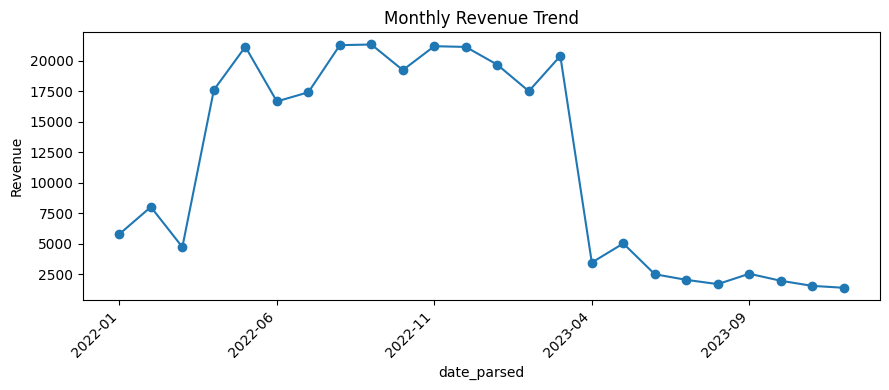

In [16]:
# Monthly revenue trend
monthly_revenue = df.groupby(df['date_parsed'].dt.to_period('M'))['transaction_amount'].sum().sort_index()
monthly_revenue.index = monthly_revenue.index.astype(str)
plt.figure(figsize=(9, 4))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

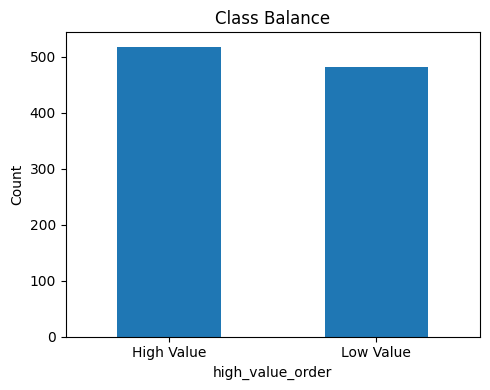

In [ ]:
# Target balance
class_dist = df['high_value_order'].map({0: 'Low Value', 1: 'High Value'}).value_counts()
plt.figure(figsize=(5, 4))
class_dist.plot(kind='bar')
plt.title('Class Balance')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Prepare features and train/test split

In [18]:
features = [
    'item_name', 'item_type', 'item_price', 'transaction_type',
    'received_by', 'time_of_sale', 'month', 'day', 'dayofweek',
    'weekend', 'quarter'
]

target = 'high_value_order'
X = df[features]
y = df[target]

cat_cols = ['item_name', 'item_type', 'transaction_type', 'received_by', 'time_of_sale']
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(800, 11) (200, 11)


## 6. Model training + hyperparameter tuning

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('preprocess', preprocess),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(random_state=42, n_jobs=1))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocess', preprocess),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}

param_grids = {
    'Logistic Regression': {
        'model__C': [0.1, 1.0, 10.0],
        'model__solver': ['liblinear']
    },
    'Decision Tree': {
        'model__max_depth': [3, 5, None],
        'model__min_samples_split': [2, 10]
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, None]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3]
    }
}

In [20]:
results = []
best_estimators = {}
roc_curves = {}

for model_name, pipe in pipelines.items():
    grid = GridSearchCV(pipe, param_grids[model_name], scoring='f1', cv=cv, n_jobs=1)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    best_estimators[model_name] = best

    y_pred = best.predict(X_test)
    y_prob = best.predict_proba(X_test)[:, 1]

    results.append({
        'Model': model_name,
        'Best CV F1': grid.best_score_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves[model_name] = (fpr, tpr)

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df

,Model,Best CV F1,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,0.693160,0.750,0.806818,0.682692,0.739583,0.781400
2,Random Forest,0.708336,0.745,0.791209,0.692308,0.738462,0.770833
3,Gradient Boosting,0.710960,0.740,0.782609,0.692308,0.734694,0.767077
0,Logistic Regression,0.710138,0.740,0.802326,0.663462,0.726316,0.771635


## 7. ROC curve comparison

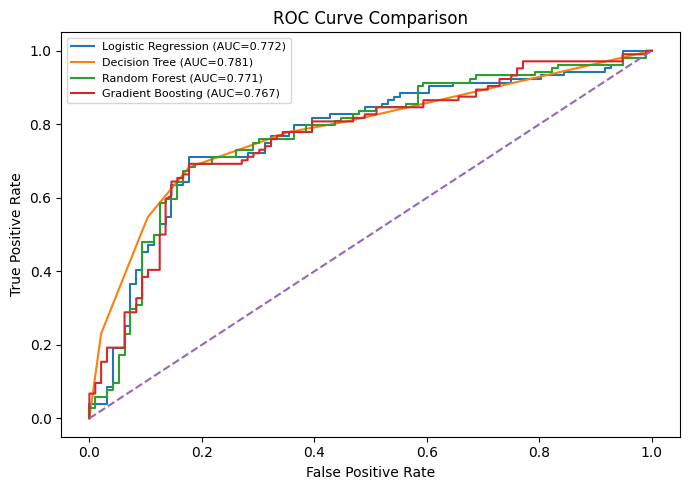

In [21]:
plt.figure(figsize=(7, 5))
for model_name, (fpr, tpr) in roc_curves.items():
    auc = results_df.loc[results_df['Model'] == model_name, 'ROC-AUC'].values[0]
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Feature importance from the best model

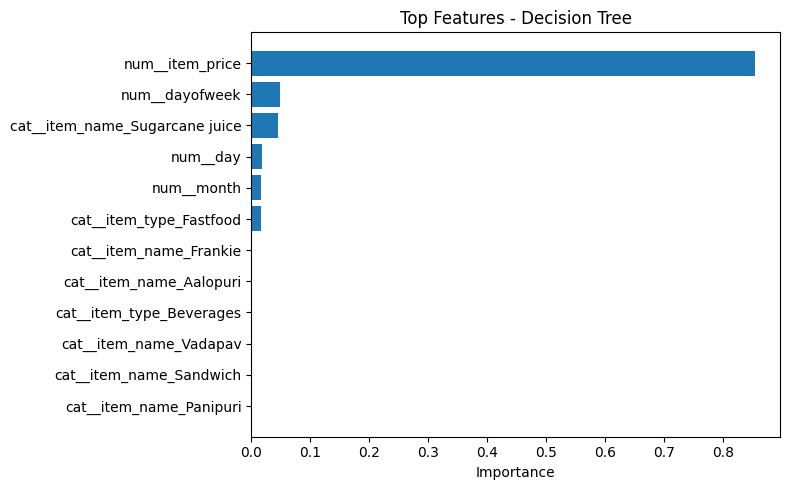

,feature,importance
18,num__item_price,0.854515
21,num__dayofweek,0.048412
5,cat__item_name_Sugarcane juice,0.045952
20,num__day,0.018918
19,num__month,0.016103
8,cat__item_type_Fastfood,0.016100
2,cat__item_name_Frankie,0.000000
0,cat__item_name_Aalopuri,0.000000
7,cat__item_type_Beverages,0.000000
6,cat__item_name_Vadapav,0.000000


In [22]:
best_model_name = results_df.iloc[0]['Model']
best_model = best_estimators[best_model_name]
model = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

if hasattr(model, 'feature_importances_'):
    scores = model.feature_importances_
else:
    scores = np.abs(model.coef_[0])

importance_df = pd.DataFrame({'feature': feature_names, 'importance': scores})     .sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.title(f'Top Features - {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importance_df

## 9. Final conclusion

- The project compares four classification models.
- The strongest model in the prepared project package is the **Decision Tree**.
- This model achieved the best balance between precision and recall on the test set.
- The most useful predictive signals come from menu item, item price, transaction type, and timing features.
- A natural future extension would be to collect customer-level or store-level data for stronger demand forecasting.


In [23]:
print('Notebook fix check complete.')
print('Dataset rows:', len(df))
print('Best model:', results_df.iloc[0]['Model'])

Notebook fix check complete.
Dataset rows: 1000
Best model: Decision Tree
